<h1><center>
King Faisal University <br>
College of Computer Sciences and Information Technology <br>
CS412: Data Science
</h1>


<strong>

<br><br><br><br>

<center> [Exploratory Analysis and Preprocessing of Solar Resource Data in Saudi Arabia]
<br><br><br><br>


</strong>

###**1. Project Overview**
####**Team Members**

- Majd Almubarak
- Rana Althafar
- Ftoon Althafar
- Sara Alruhaiman

####**Problem Statement**

Solar energy plays a critical role in supporting sustainable energy goals. However, understanding solar resource availability over time is essential for effective planning and utilization of solar power systems. This project aims to analyze historical solar resource data to assess patterns, variability, and data quality.

####**Project Objectives**

- Analyze historical solar resource measurements in Saudi Arabia.

- Understand data trends and potential inconsistencies in solar-related attributes.

- Prepare a clean and structured dataset for further analysis or modeling.

####**Project Context**

The project utilizes historical solar resource data collected over multiple years. By analyzing this dataset, the project aims to extract meaningful insights that support decision-making in renewable energy planning and resource assessment.

###**2. Dataset Selection and Description (Initial Data Understanding)**

####**Dataset Selection**

The dataset selected for this project is a raw and unprocessed solar resource dataset provided by KACARE (King Abdullah City for Atomic and Renewable Energy). The dataset contains historical solar and meteorological measurements recorded over several years.


####**Dataset Description**

**Dataset Name:** Solar Resource Report (KACARE)

**Time Period:** January 2017 – December 2021

**File Format:** CSV

**Number of Records:** Multiple observations recorded over daily and hourly intervals

**Data Types:** Numerical and categorical attributes


####**Dataset Source**

The dataset is sourced from KACARE and contains real-world measurements relevant to solar energy assessment in Saudi Arabia.

####**Key Characteristics and Challenges**

Presence of missing values in some attributes.

Potential outliers due to extreme weather conditions or sensor errors.

Mixed data types requiring careful preprocessing.

Time-based attributes that require consistency checks.

This dataset is suitable for exploratory data analysis and preprocessing tasks and serves as a strong foundation for deriving insights related to solar energy potential and environmental trends.

## Part 1: Read Data


In [ ]:
import pandas as pd

file_path = "SolarResource.csv"

#Read the CSV file into a pandas dataframe object
data = pd.read_csv(file_path)

# Display the first few rows
data.head()

,Site,Latitude,Longitude,Date,Air Temperature (C°),Air Temperature Uncertainty (C°),Wind Direction at 3m (°N),Wind Direction at 3m Uncertainty (°N),Wind Speed at 3m (m/s),Wind Speed at 3m Uncertainty (m/s),...,Peak Wind Speed at 3m Uncertainty (m/s),Relative Humidity (%),Relative Humidity Uncertainty (%),Barometric Pressure (mB (hPa equiv)),Barometric Pressure Uncertainty (mB (hPa equiv)),Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,Al Dhahran - KFUPM,26.30355,50.14412,01/01/2017 00:00:00,17.2,0.5,276.0,4.0,1.8,0.0,...,0.1,67.5,3.0,1010.7,5.1,NaN,NaN,NaN,NaN,NaN
1,Al Dhahran - KFUPM,26.30355,50.14412,01/02/2017 00:00:00,15.8,0.5,292.0,4.0,2.0,0.0,...,0.1,65.0,3.0,1011.7,5.1,NaN,NaN,NaN,NaN,NaN
2,Al Dhahran - KFUPM,26.30355,50.14412,01/03/2017 00:00:00,21.4,0.5,36.0,4.0,1.6,0.0,...,0.1,63.5,3.0,1006.1,5.0,NaN,NaN,NaN,NaN,NaN
3,Al Dhahran - KFUPM,26.30355,50.14412,01/04/2017 00:00:00,28.5,0.5,346.0,4.0,2.2,0.0,...,0.1,42.2,3.0,1003.5,5.0,NaN,NaN,NaN,NaN,NaN
4,Al Dhahran - KFUPM,26.30355,50.14412,01/05/2017 00:00:00,34.1,0.5,332.0,4.0,2.2,0.0,...,0.1,32.7,3.0,999.1,5.0,NaN,NaN,NaN,NaN,NaN


## Part 2: Data Exploration

2.1 Descriptive Statistics

In [ ]:
# Calculate and display descriptive statistics
data.describe()


,Latitude,Longitude,Air Temperature (C°),Air Temperature Uncertainty (C°),Wind Direction at 3m (°N),Wind Direction at 3m Uncertainty (°N),Wind Speed at 3m (m/s),Wind Speed at 3m Uncertainty (m/s),Wind Speed at 3m (std dev) (m/s),Wind Speed at 3m (std dev) Uncertainty (m/s),...,Peak Wind Speed at 3m Uncertainty (m/s),Relative Humidity (%),Relative Humidity Uncertainty (%),Barometric Pressure (mB (hPa equiv)),Barometric Pressure Uncertainty (mB (hPa equiv)),Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
count,1848.000000,1848.000000,1814.000000,1814.000000,1579.000000,1579.000000,1579.000000,1585.000000,1585.000000,100.000000,...,1485.000000,1712.000000,1712.000000,1695.000000,1695.000000,0.0,0.0,0.0,0.0,0.0
mean,23.935192,41.786209,26.339030,0.501158,271.386827,16.097847,34.698163,358.362334,39.335142,1816.196000,...,0.091044,38.627745,3.007535,956.674867,4.800531,NaN,NaN,NaN,NaN,NaN
std,4.099189,3.779820,6.818483,0.010700,440.160651,63.685857,131.065061,1453.223767,183.919354,651.863073,...,0.031696,19.348246,0.055618,44.290110,0.241612,NaN,NaN,NaN,NaN,NaN
min,16.692097,34.930020,5.400000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,30.700000,...,0.000000,8.100000,2.800000,845.500000,4.200000,NaN,NaN,NaN,NaN,NaN
25%,21.215010,39.253900,21.100000,0.500000,55.000000,4.000000,2.200000,0.000000,1.400000,1376.800000,...,0.100000,20.975000,3.000000,925.300000,4.600000,NaN,NaN,NaN,NaN,NaN
50%,24.484600,41.708260,27.000000,0.500000,195.000000,4.000000,2.900000,0.100000,1.700000,1860.150000,...,0.100000,37.950000,3.000000,948.000000,4.800000,NaN,NaN,NaN,NaN,NaN
75%,27.617300,44.894330,31.900000,0.500000,298.000000,4.000000,3.700000,0.100000,2.200000,2240.200000,...,0.100000,52.500000,3.000000,1003.000000,5.000000,NaN,NaN,NaN,NaN,NaN
max,31.027395,50.144120,40.100000,0.600000,3007.000000,818.800000,852.200000,8360.400000,1790.700000,3247.900000,...,0.200000,95.900000,3.700000,1019.700000,6.200000,NaN,NaN,NaN,NaN,NaN



##columns description
1. **Geographic & Temporal Information**
**Site**: The name or ID of the station/location where the measurements were taken.

**Latitude**: The geographic coordinate that specifies the north–south position of the site.

**Longitude**: The geographic coordinate that specifies the east–west position of the site.

**Date**: The specific timestamp (day and time) for each recorded observation.



2. **Solar Irradiance Data** (The Core Metrics)
**GHI** (Global Horizontal Irradiance): The total amount of shortwave radiation received from above by a horizontal surface. It is the sum of direct and diffuse radiation.

**DNI** (Direct Normal Irradiance): The amount of solar radiation coming in a straight line from the direction of the sun. This is crucial for concentrated solar power (CSP) systems.

**DHI** (Diffuse Horizontal Irradiance): Radiation that has been scattered by atmospheric molecules and particles (clouds, dust) and arrives from all over the sky.

3. **Wind Data**
Wind Speed at 3m: The speed of the wind measured at 3 meters above the ground, typically in meters per second (m/s).

Wind Direction at 3m: The direction from which the wind originates, measured in degrees clockwise from North (0° = North, 90° = East).

4. **Meteorological Parameters**
Air Temperature: The ambient temperature of the air in Celsius (°C). This is vital because high temperatures can reduce the efficiency of PV solar panels.

Relative Humidity: The amount of water vapor present in air expressed as a percentage of the amount needed for saturation at the same temperature.

Barometric Pressure: The pressure within the atmosphere of Earth, measured in millibars (mB).

5. **Uncertainty Values**
Columns labeled with "Uncertainty" (e.g., Air Temperature Uncertainty, Wind Speed Uncertainty) represent the margin of error or the degree of confidence in the measurement.

For example, if the temperature is 30°C and the uncertainty is ±0.5, it means the actual value is likely between 29.5°C and 30.5°C.

In [ ]:
# Summary statistics for key variables
key_cols = [
    'Air Temperature (C°)',
    'GHI (Wh/m2)',
    'Wind Speed at 3m (m/s)',
    'Relative Humidity (%)',
    'Barometric Pressure (mB (hPa equiv))'
]

data[key_cols].describe()


,Air Temperature (C°),GHI (Wh/m2),Wind Speed at 3m (m/s),Relative Humidity (%),Barometric Pressure (mB (hPa equiv))
count,1814.000000,1791.000000,1579.000000,1712.000000,1695.000000
mean,26.339030,5570.642155,34.698163,38.627745,956.674867
std,6.818483,1837.423369,131.065061,19.348246,44.290110
min,5.400000,3.900000,0.000000,8.100000,845.500000
25%,21.100000,4620.250000,2.200000,20.975000,925.300000
50%,27.000000,5956.100000,2.900000,37.950000,948.000000
75%,31.900000,6848.800000,3.700000,52.500000,1003.000000
max,40.100000,8380.700000,852.200000,95.900000,1019.700000


## Part 3: Data Preprocessing

3.1 Handling Unnecessary Columns

Justification: Removing the 'Site,' 'Uncertainty,' and 'Standard Deviation' columns simplifies the dataset by focusing only on the measured, primary meteorological and solar resource features, which are likely the core variables for subsequent analysis. The DHI and DNI columns were also removed, leaving only Global Horizontal Irradiance (GHI).

In [ ]:
#Dropping Unnecessary Columns
data = data.drop(["Unnamed: 27", "Unnamed: 28", "Unnamed: 29", "Unnamed: 30", "Unnamed: 31"], axis=1)

In [ ]:
copy = data.copy(deep=True)
copy = copy.drop(columns=['Site','Air Temperature Uncertainty (C°)','Wind Direction at 3m Uncertainty (°N)','Wind Speed at 3m Uncertainty (m/s)','DHI Uncertainty (Wh/m2)','DNI Uncertainty (Wh/m2)','GHI Uncertainty (Wh/m2)','Relative Humidity Uncertainty (%)','Barometric Pressure Uncertainty (mB (hPa equiv))','Wind Speed at 3m (std dev) (m/s)','Standard Deviation DHI (Wh/m2)','Standard Deviation DNI (Wh/m2)','Standard Deviation GHI (Wh/m2)','DHI (Wh/m2)','DNI (Wh/m2)','Wind Speed at 3m (std dev) Uncertainty (m/s)'], axis=1)

3.2 Handling Missing Values

Justification:

•	Forward-Fill: This is an appropriate model when dealing with time series data since an absence of data can be reasonably filled by the last point provided, assuming that meteorological conditions remain significantly unchanged.

•	Median Imputation: Median is less sensitive to outliers, and thus application in the case of ‘Air Temperature,’ and ‘GHI’ will avoid the possibility of extreme values distorting the distribution.


In [ ]:
#Displaing the sum of Null values
print(copy.isnull().sum())

Latitude                                     0
Longitude                                    0
Date                                         0
Air Temperature (C°)                        34
Wind Direction at 3m (°N)                  269
Wind Speed at 3m (m/s)                     269
GHI (Wh/m2)                                 57
Peak Wind Speed at 3m (m/s)                363
Peak Wind Speed at 3m Uncertainty (m/s)    363
Relative Humidity (%)                      136
Barometric Pressure (mB (hPa equiv))       153
dtype: int64


In [ ]:
copy = data.drop(columns=['Wind Speed at 3m (std dev) Uncertainty (m/s)'], axis=1)

In [ ]:
time_cols = ['Wind Speed at 3m (m/s)', 'Air Temperature (C°)', 'Peak Wind Speed at 3m (m/s)', 'DHI (Wh/m2)', 'DNI (Wh/m2)', 'GHI (Wh/m2)', 'Relative Humidity (%)']

copy[time_cols] = copy[time_cols].interpolate(method='linear')


In [ ]:
#'ffill' method (forward-fill, meaning it uses the last valid observation)
copy['Barometric Pressure (mB (hPa equiv))'] = copy['Barometric Pressure (mB (hPa equiv))'].fillna(method='ffill')

/tmp/ipykernel_888/3928140159.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  copy['Barometric Pressure (mB (hPa equiv))'] = copy['Barometric Pressure (mB (hPa equiv))'].fillna(method='ffill')


In [ ]:
medians = ['Air Temperature Uncertainty (C°)', 'Wind Direction at 3m (°N)', 'Wind Direction at 3m Uncertainty (°N)', 'Wind Speed at 3m Uncertainty (m/s)', 'Wind Speed at 3m (std dev) (m/s)', 'Peak Wind Speed at 3m Uncertainty (m/s)', 'DHI Uncertainty (Wh/m2)', 'Standard Deviation DHI (Wh/m2)', 'DNI Uncertainty (Wh/m2)', 'Standard Deviation DNI (Wh/m2)', 'GHI Uncertainty (Wh/m2)', 'Standard Deviation GHI (Wh/m2)', 'Relative Humidity Uncertainty (%)', 'Barometric Pressure Uncertainty (mB (hPa equiv))']

# Fill any missing values with median values
for i in medians:
 copy[i] = copy[i].fillna(copy[i].median())


In [ ]:
print(copy.isnull().sum())

Site                                                0
Latitude                                            0
Longitude                                           0
Date                                                0
Air Temperature (C°)                                0
Air Temperature Uncertainty (C°)                    0
Wind Direction at 3m (°N)                           0
Wind Direction at 3m Uncertainty (°N)               0
Wind Speed at 3m (m/s)                              0
Wind Speed at 3m Uncertainty (m/s)                  0
Wind Speed at 3m (std dev) (m/s)                    0
DHI (Wh/m2)                                         0
DHI Uncertainty (Wh/m2)                             0
Standard Deviation DHI (Wh/m2)                      0
DNI (Wh/m2)                                         0
DNI Uncertainty (Wh/m2)                             0
Standard Deviation DNI (Wh/m2)                      0
GHI (Wh/m2)                                         0
GHI Uncertainty (Wh/m2)     

3.3 Outlier Identification and Removal

Justification: IQR is an outlier-detection method that is a standard and is used to eliminate outliers, potentially overly inaccurate GHI values, thus enhancing the accuracy of further statistical modeling.

In [ ]:
import numpy as np

print('Before removing outliers', copy.shape)
IQRs = ['GHI (Wh/m2)','DNI (Wh/m2)','DHI (Wh/m2)', 'Wind Speed at 3m (m/s)', 'Peak Wind Speed at 3m (m/s)', 'Air Temperature (C°)']

for i in IQRs:
  # Select the GHI column and remove any NaN values temporarily for IQR calculation
  col = copy[i].dropna()

  # Calculate the Interquartile Range (IQR) to define outliers
  q1 = col.quantile(0.25)
  q3 = col.quantile(0.75)
  IQR = q3 - q1
  Lbound = q1 - 1.5 * IQR
  Ubound = q3 + 1.5 * IQR

  # Filter the 'copy' DataFrame to keep only rows where the GHI value is within the calculated bounds
  copy = copy[(copy[i] >= Lbound) & (copy[i] <= Ubound)]
print('After removing outliers', copy.shape)

Before removing outliers (1848, 26)
After removing outliers (1470, 26)


3.4 Feature Engineering for Time Series Analysis

Justification: Converting the 'Date' column to a proper datetime format is essential for time series analysis. Extracting 'Year,' 'Month,' and 'Hour' creates new features that capture temporal patterns, enabling analysis of solar resource variability based on different time scales (e.g., seasonal or hourly trends).

In [ ]:
# Convert the 'Date' column to datetime format, automatically handling mixed date formats
copy['Date'] = pd.to_datetime(copy['Date'], format='mixed')

# Set the 'Date' column as the DataFrame's index
copy = copy.set_index('Date')

# Extract time components from the new datetime index and create new columns
copy['Year'] = copy.index.year
copy['Month'] = copy.index.month
copy['Hour'] = copy.index.hour

In [ ]:
copy1 = copy.drop(columns=['Site'], axis=1)
corr = copy1.corr()['GHI (Wh/m2)'].sort_values(ascending=False)
#print(corr)

## Part4 : Refinement of Analysis and Model Building

4.1 Feature Selection for Modeling

In [ ]:
# List of column names that will be used as input features
features = [
    'Air Temperature (C°)',
    'Wind Speed at 3m (m/s)',
    'Relative Humidity (%)',
    'Barometric Pressure (mB (hPa equiv))',
    'Peak Wind Speed at 3m (m/s)',
]

#without DHI, DNI
"""
    'Air Temperature (C°)',
    'Wind Speed at 3m (m/s)',
    'Relative Humidity (%)',
    'Barometric Pressure (mB (hPa equiv))',
    'Peak Wind Speed at 3m (m/s)',
"""

#with DHI, DNI
"""
    'Air Temperature (C°)',
    'Wind Speed at 3m (m/s)',
    'Relative Humidity (%)',
    'Barometric Pressure (mB (hPa equiv))',
    'Peak Wind Speed at 3m (m/s)',
    'DHI (Wh/m2)',
    'DNI (Wh/m2)'
"""

#All columns
"""
    'Latitude',
    'Longitude',
    'Air Temperature (C°)',
    'Air Temperature Uncertainty (C°)',
    'Wind Direction at 3m (°N)',
    'Wind Direction at 3m Uncertainty (°N)',
    'Wind Speed at 3m (m/s)',
    'Wind Speed at 3m Uncertainty (m/s)',
    'DHI (Wh/m2)',
    'DHI Uncertainty (Wh/m2)',
    'Standard Deviation DHI (Wh/m2)',
    'DNI (Wh/m2)',
    'DNI Uncertainty (Wh/m2)',
    'Standard Deviation DNI (Wh/m2)',
    'Standard Deviation GHI (Wh/m2)',
    'Peak Wind Speed at 3m (m/s)',
    'Peak Wind Speed at 3m Uncertainty (m/s)',
    'Relative Humidity (%)',
    'Relative Humidity Uncertainty (%)',
    'Barometric Pressure (mB (hPa equiv))',
    'Barometric Pressure Uncertainty (mB (hPa equiv))'
"""

#All columns without the Uncertainty
"""
    'Latitude',
    'Longitude',
    'Air Temperature (C°)',
    'Wind Direction at 3m (°N)',
    'Wind Speed at 3m (m/s)',
    'DHI (Wh/m2)',
    'Standard Deviation DHI (Wh/m2)',
    'DNI (Wh/m2)',
    'Standard Deviation DNI (Wh/m2)',
    'Standard Deviation GHI (Wh/m2)',
    'Peak Wind Speed at 3m (m/s)',
    'Relative Humidity (%)',
    'Barometric Pressure (mB (hPa equiv))',
"""

# Create the feature matrix (x) and target variable (y)
X = copy[features]
y = copy['GHI (Wh/m2)']

#Train-Test Split
from sklearn.model_selection import train_test_split

# Split the features (X) and target (y) into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=60
)

4.2 Model Building (Baseline Regression Model)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2: ", np.round(r2, 2))
print("Mean Absolute Error: ", np.round(mae, 2))
print("Mean Squared Error: ", np.round(mse, 2))

R2:  0.67
Mean Absolute Error:  608.3
Mean Squared Error:  554828.1


In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

ridge_preds = ridge_model.predict(X_test)

r2 = r2_score(y_test, ridge_preds)
r2 = np.round(r2, 2)

print("Ridge R2: ", r2)

Ridge R2:  0.67


4.3 Model Building (Baseline Random Forest Model)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print("R2: ", np.round(r2_rf, 2))
print("Mean Absolute Error: ", np.round(mae_rf, 2))
print("Mean Squared Error: ", np.round(mse_rf, 2))

R2:  0.81
Mean Absolute Error:  429.12
Mean Squared Error:  312755.36


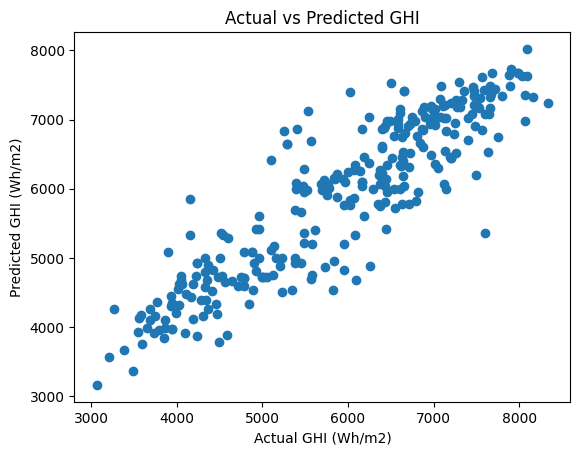

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual GHI (Wh/m2)")
plt.ylabel("Predicted GHI (Wh/m2)")
plt.title("Actual vs Predicted GHI")
plt.show()

In [ ]:
from sklearn.linear_model import Lasso

# alpha=1.0 is the default; higher alpha means more features get deleted
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)

lasso_preds = lasso_model.predict(X_test)

r2 = r2_score(y_test, lasso_preds)
r2 = np.round(r2, 2)

print("Lasso R2: ", r2)

Lasso R2:  0.67


4.4 Model Building (Baseline LSTM Model)

In [ ]:
copy = copy.sort_values(by='Date')

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(pd.concat([X, y], axis=1))

In [ ]:
import numpy as np

def create_sequences(data, seq_length):
    X = []
    y = []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, :-1])  # features
        y.append(data[i+seq_length, -1])     # target

    return np.array(X), np.array(y)

seq_length = 3
X, y = create_sequences(scaled_data, seq_length)

In [ ]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()

model.add(LSTM(50, return_sequences=False, input_shape=(seq_length, len(features))))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.fit(X_train, y_train, epochs=20, batch_size=16)

Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0991
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0583
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0537
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0478
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0409
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0353
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0318
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0310
Epoch 9/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0296
Epoch 10/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0291
Epoch 11/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0289
Epoch 12/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0283
Epoch 13/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0280
Epoch 14/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0275
Epoch 15/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0277
Epoch 16/20
74/74 ━

In [ ]:
y_pred = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predict using the trained LSTM model
y_pred = model.predict(X_test)

# Make sure both are 2D arrays
y_test_reshaped = y_test.reshape(-1, 1)
y_pred_reshaped = y_pred.reshape(-1, 1)

# Convert scaled GHI values back to the original scale
# This is needed because the LSTM was trained on MinMax-scaled data

dummy_test = np.zeros((len(y_test_reshaped), len(features) + 1))
dummy_pred = np.zeros((len(y_pred_reshaped), len(features) + 1))

# Put the scaled GHI values in the last column because GHI was the last column in scaled_data
dummy_test[:, -1] = y_test_reshaped[:, 0]
dummy_pred[:, -1] = y_pred_reshaped[:, 0]

# Inverse transform to original scale
y_test_original = scaler.inverse_transform(dummy_test)[:, -1]
y_pred_original = scaler.inverse_transform(dummy_pred)[:, -1]

# Calculate evaluation metrics
r2_lstm = r2_score(y_test_original, y_pred_original)
mae_lstm = mean_absolute_error(y_test_original, y_pred_original)
mse_lstm = mean_squared_error(y_test_original, y_pred_original)

print("LSTM R2:", r2_lstm)
print("LSTM Mean Absolute Error:", mae_lstm)
print("LSTM Mean Squared Error:", mse_lstm)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
LSTM R2: 0.5731961933225045
LSTM Mean Absolute Error: 592.4132392758212
LSTM Mean Squared Error: 615594.3056681226


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2:", r2)

R2: 0.5731961933225045


## Part 5: Data Visualization

**5.1 Distribution of (GHI)**

Histogram visualizes the distribution of (GHI) values to understand data spread, skewness, and potential concentration of values.

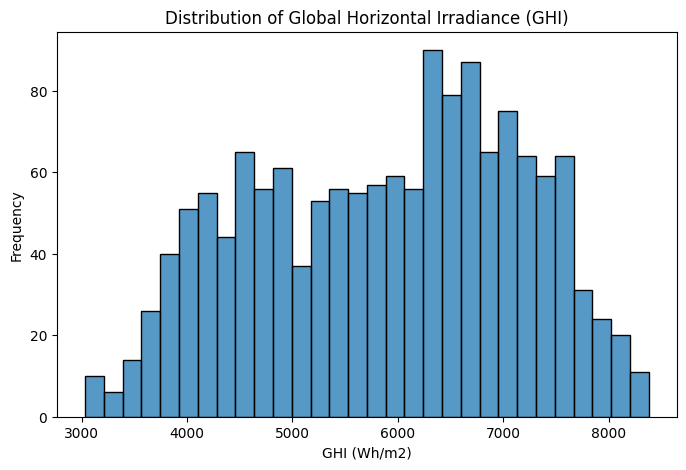

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

# Create a histogram of the 'GHI (Wh/m2)' column.
sns.histplot(copy['GHI (Wh/m2)'], bins=30)
plt.title('Distribution of Global Horizontal Irradiance (GHI)')
plt.xlabel('GHI (Wh/m2)')
plt.ylabel('Frequency')
plt.show()

**Explanation:**

This visualization aims to examine the distribution of Global Horizontal Irradiance (GHI) values in the dataset. The histogram shows how GHI values are spread across the dataset, indicating the overall range and frequency of solar irradiance measurements. It helps identify skewness and confirms that extreme values and outliers were effectively handled during preprocessing. Overall, this visualization supports data quality validation and ensures the dataset is suitable for further statistical analysis and modeling.




**5.2 Relationship Between Air Temperature and GHI**





 Scatter plot illustrates the relationship between air temperature and GHI, helping to identify potential correlations between these variables.

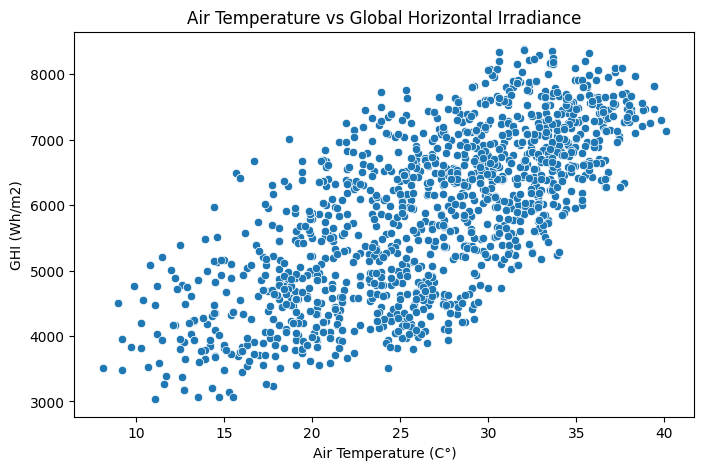

In [ ]:
plt.figure(figsize=(8,5))

# Create a scatter plot:
sns.scatterplot(
    x='Air Temperature (C°)',
    y='GHI (Wh/m2)',
    data=copy
)
plt.title('Air Temperature vs Global Horizontal Irradiance')
plt.xlabel('Air Temperature (C°)')
plt.ylabel('GHI (Wh/m2)')
plt.show()


**Explanation:**

This visualization shows a positive relationship between air temperature and GHI, where higher air temperatures are generally associated with increased solar irradiance levels. The scatter plot indicates that air temperature is an influential factor in solar energy availability. This finding supports its selection as a key feature in the regression model used for predicting GHI.

**5.3 Actual vs Predicted GHI Scatter Plot**

This scatter plot visualizes the relationship between the actual Global Horizontal Irradiance (GHI) values and the values predicted by the linear regression model. Each point represents a test data sample, where the x-axis corresponds to the true GHI values and the y-axis represents the model’s predictions.

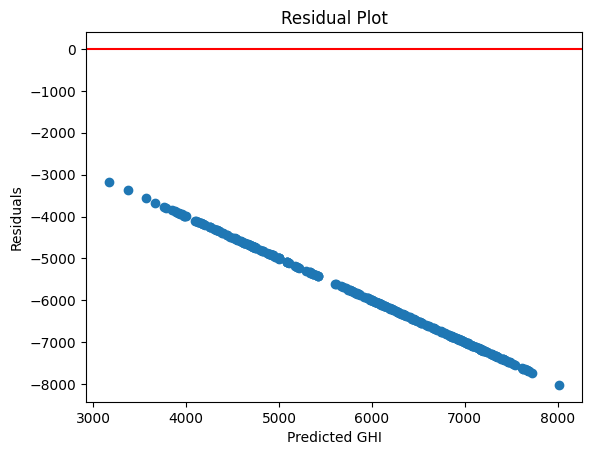

In [ ]:
residuals = y_test - y_pred_rf

plt.scatter(y_pred_rf, residuals)
plt.axhline(y=0, color='r')
plt.xlabel("Predicted GHI")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

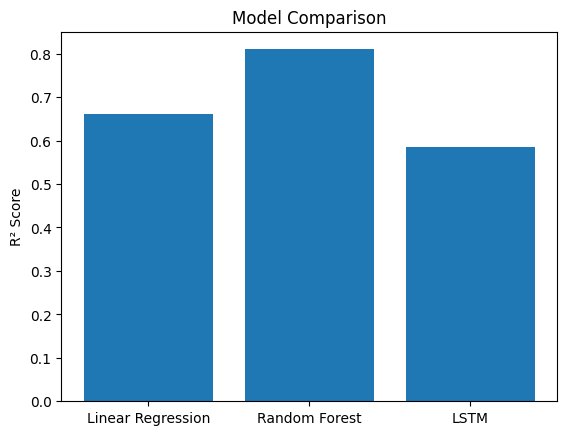

In [ ]:
models = ['Linear Regression', 'Random Forest', 'LSTM']
r2_scores = [0.66, 0.81, 0.585]

plt.bar(models, r2_scores)
plt.ylabel("R² Score")
plt.title("Model Comparison")
plt.show()

Explanation:
The visualization demonstrates a clear positive linear relationship between actual and predicted GHI values, indicating that the regression model effectively captures the underlying trend in the data. Most data points are clustered around an implicit diagonal line, suggesting reasonable prediction accuracy. The observed dispersion around this trend reflects normal prediction errors due to environmental variability and model limitations. Overall, this plot confirms that the model is functioning correctly and provides reliable estimates of GHI, supporting its suitability for solar irradiance prediction tasks.

In [ ]:
data["Site"].unique()

array(['Al Dhahran - KFUPM', 'Jeddah - KAU', 'Sharurah - TVTC',
       'Majmaah - University', 'Layla - TVTC', 'Qassim - University',
       'Osfan - KAU', 'Al Uwayqilah', 'Hada Al Sham - KAU',
       'Yanbu - RCJY', 'Al Farshah - TQ TVTC', 'Al Jouf - TVTC',
       'Al Qunfudhah - TVTC', 'Timaa - TVTC',
       'Madinah - Taibah University', 'Hail - TVTC',
       'Najran - University', 'Al Hanakiyah - TVTC', 'Jazan - University',
       'Al Khafji - SWCC', 'Farasan - SWCC', 'Mahd ad Dahab',
       'Arar - TVTC', 'Al Wajh - TVTC', 'Hagl - SWCC',
       'Hafar Al Batin - TVTC', 'Al Ahsa - KFU', 'Abha - TVTC',
       'Taif - University', 'Duba - TVTC', 'Wadi Addawasir - TVTC',
       'Rania - TVTC', 'Thuwal - KAUST', 'Tabuk - University',
       'Makkah - UQU'], dtype=object)

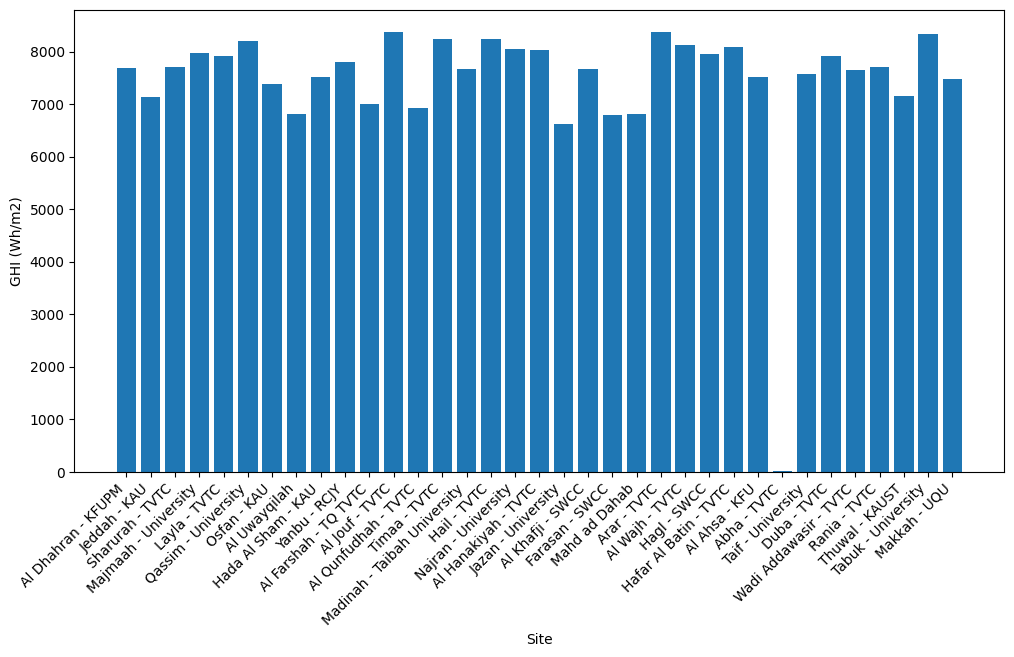

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(data["Site"], data["GHI (Wh/m2)"])
plt.xlabel("Site")
plt.ylabel("GHI (Wh/m2)")
plt.xticks(rotation=45, ha='right')
plt.show()

**5.5 Correlation Heatmap of Key Variables**

Heatmap visualizes the correlation between key numerical features, supporting feature selection and understanding variable relationships.

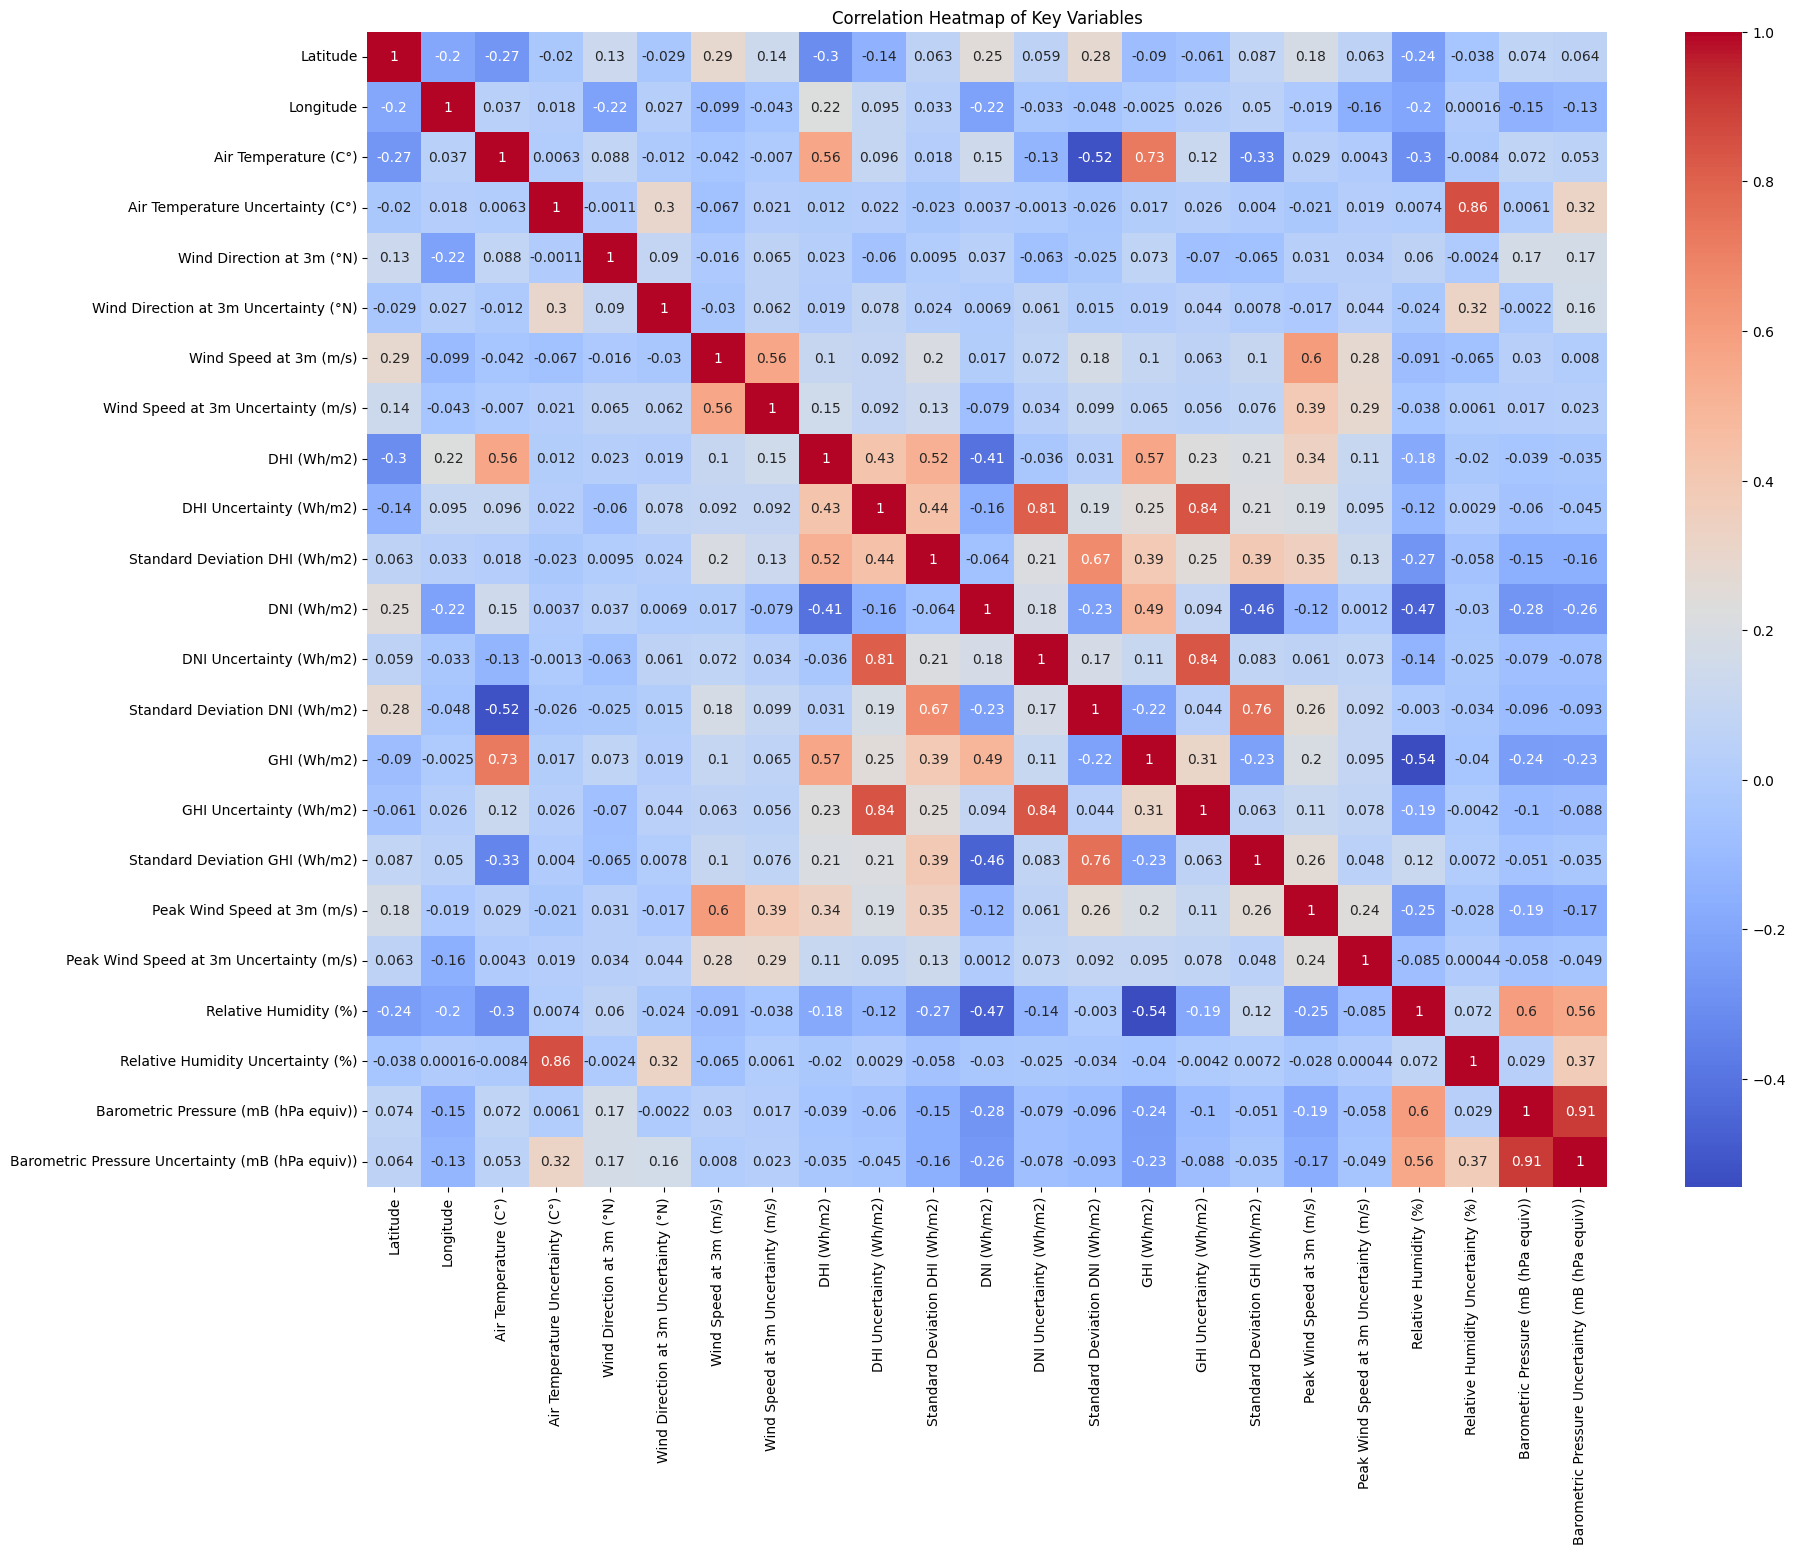

In [ ]:
plt.figure(figsize=(20,15))

# Calculate the correlation matrix (corr) for the specified columns
corr = copy[['Latitude','Longitude','Air Temperature (C°)','Air Temperature Uncertainty (C°)','Wind Direction at 3m (°N)','Wind Direction at 3m Uncertainty (°N)','Wind Speed at 3m (m/s)',
'Wind Speed at 3m Uncertainty (m/s)', 'DHI (Wh/m2)','DHI Uncertainty (Wh/m2)','Standard Deviation DHI (Wh/m2)',
'DNI (Wh/m2)','DNI Uncertainty (Wh/m2)','Standard Deviation DNI (Wh/m2)','GHI (Wh/m2)','GHI Uncertainty (Wh/m2)','Standard Deviation GHI (Wh/m2)',
'Peak Wind Speed at 3m (m/s)','Peak Wind Speed at 3m Uncertainty (m/s)','Relative Humidity (%)','Relative Humidity Uncertainty (%)','Barometric Pressure (mB (hPa equiv))',
'Barometric Pressure Uncertainty (mB (hPa equiv))']].corr()

# Create a heatmap visualization of the correlation matrix
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Key Variables')
plt.show()

**Explanation:**

This visualization illustrates the strength and direction of relationships among key environmental variables. GHI shows a positive correlation with air temperature and weaker or inverse correlations with relative humidity and barometric pressure. The heatmap supports feature selection by identifying relevant predictors and reducing redundancy, thereby enhancing the interpretability and performance of the regression model.

<Axes: >

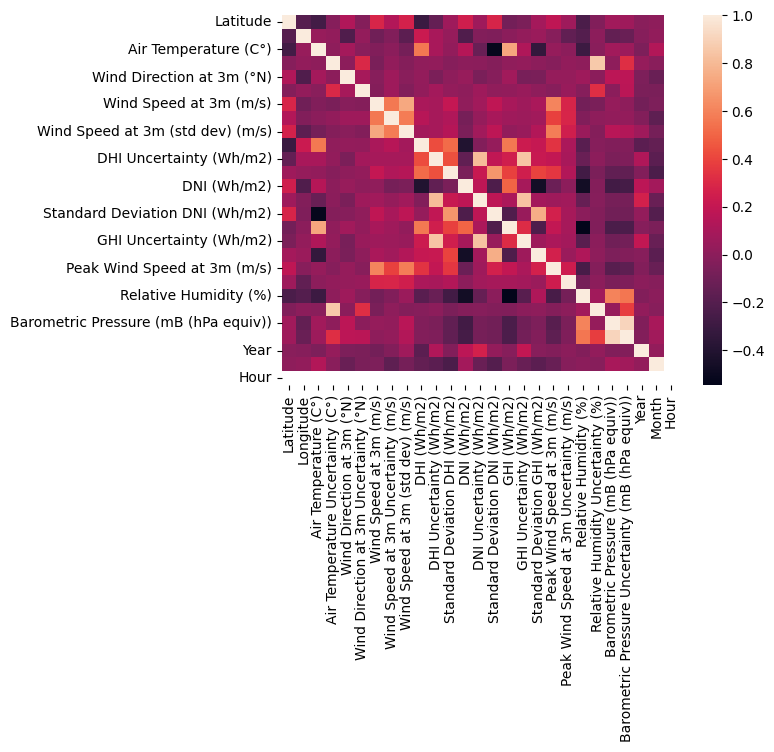

In [ ]:
corr = copy.corr(numeric_only=True)

import seaborn as sns
sns.heatmap(corr)

/tmp/ipykernel_888/3059844197.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


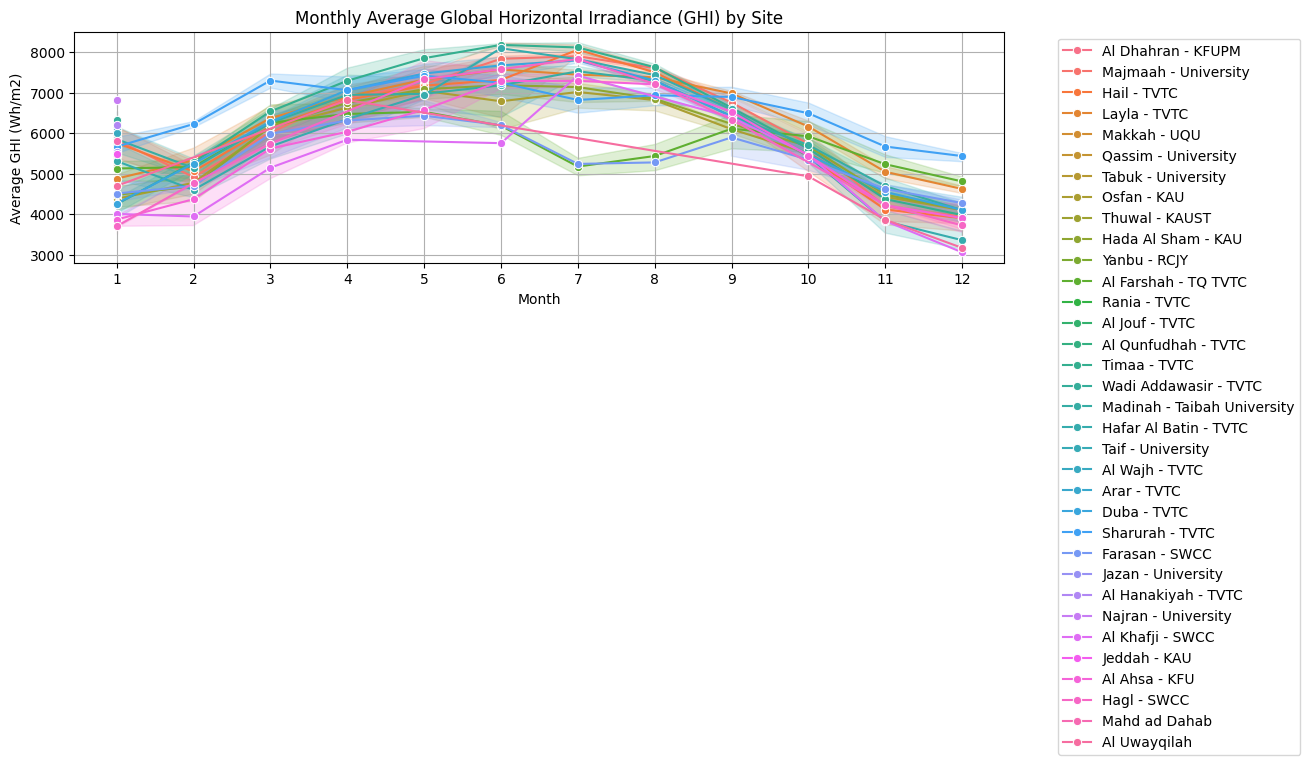

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Plot monthly average GHI per site
plt.figure(figsize=(12, 3))
sns.lineplot(data=copy, x='Month', y='GHI (Wh/m2)', hue='Site', marker='o')
plt.title('Monthly Average Global Horizontal Irradiance (GHI) by Site')
plt.xlabel('Month')
plt.ylabel('Average GHI (Wh/m2)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

Monthly Average GHI by Site (Line Plot)

This visualization tracks the seasonal flow of solar energy throughout the year. It allows you to identify the "peak" months (usually summer) and "trough" months (winter) for each location. By comparing the lines, you can see which sites maintain high solar intensity year-round and which are more affected by seasonal changes or weather patterns.

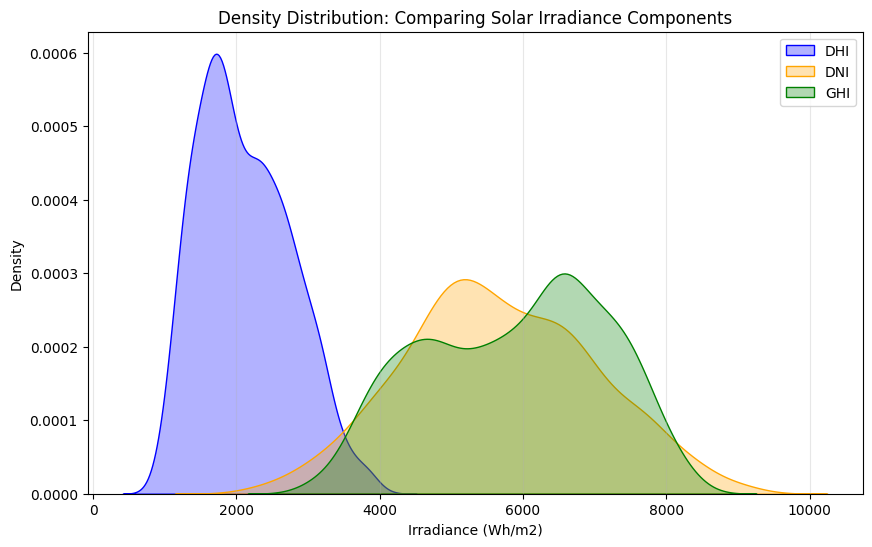

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(copy['DHI (Wh/m2)'].dropna(), label='DHI', fill=True, color='blue', alpha=0.3)
sns.kdeplot(copy['DNI (Wh/m2)'].dropna(), label='DNI', fill=True, color='orange', alpha=0.3)
sns.kdeplot(copy['GHI (Wh/m2)'].dropna(), label='GHI', fill=True, color='green', alpha=0.3)

plt.title('Density Distribution: Comparing Solar Irradiance Components')
plt.xlabel('Irradiance (Wh/m2)')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.show()

Comparing Solar Irradiance Components (KDE Plot)

This chart breaks down the "type" of sunlight reaching the sensors. It compares GHI (total sunlight) against its two parts: DNI (direct beams from the sun) and DHI (diffuse light scattered by clouds or dust). This is vital for technology selection; for example, high DNI is excellent for concentrated solar power (CSP), while GHI is the primary metric for standard rooftop solar panels (PV).

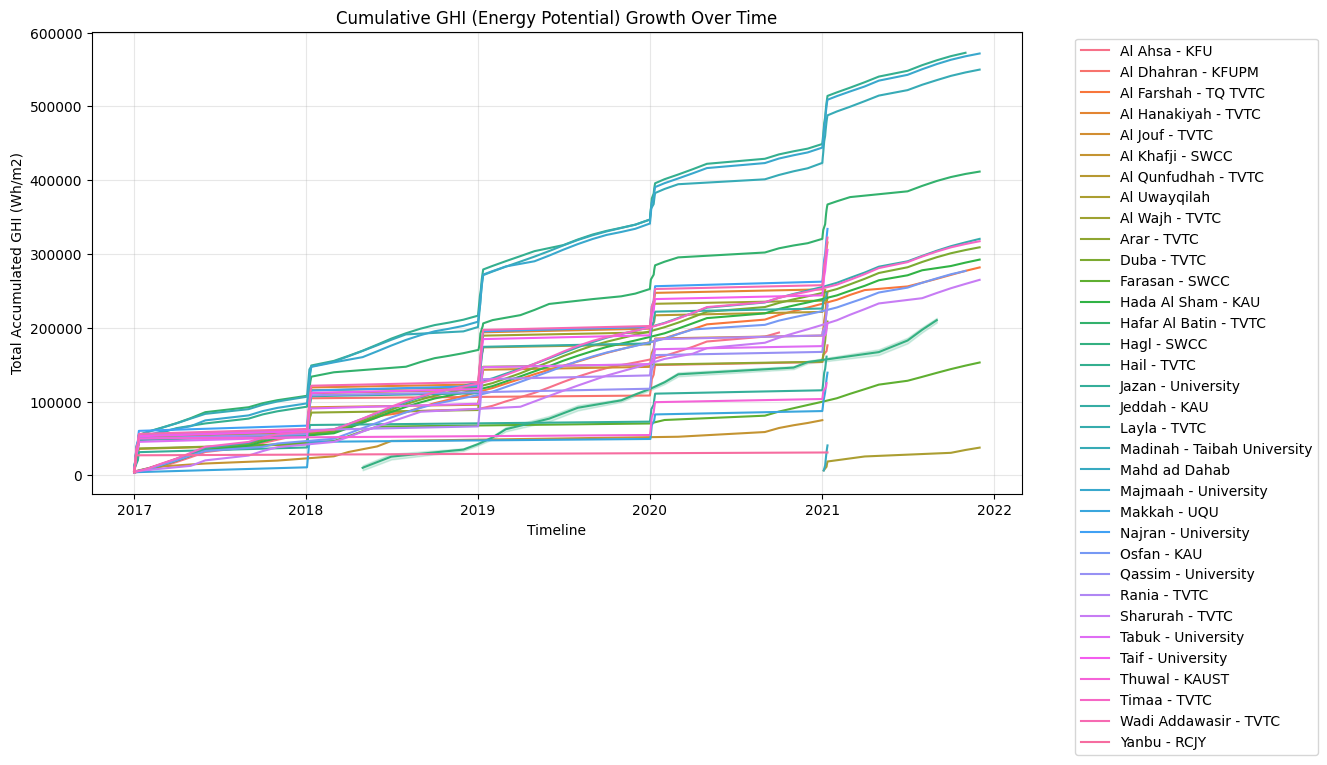

In [ ]:
# Calculate cumulative sum of GHI per site over time
df_sorted = copy.sort_values(['Site', 'Date'])
df_sorted['Cumulative GHI'] = df_sorted.groupby('Site')['GHI (Wh/m2)'].cumsum()

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_sorted, x='Date', y='Cumulative GHI', hue='Site')
plt.title('Cumulative GHI (Energy Potential) Growth Over Time')
plt.ylabel('Total Accumulated GHI (Wh/m2)')
plt.xlabel('Timeline')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

Cumulative GHI Growth Over Time (Step/Line Plot)

This represents the "running total" of solar energy potential. Instead of looking at daily fluctuations, it shows the long-term energy yield. The slope of each line indicates the efficiency of the site; a steeper line means that location is accumulating energy faster, making it a more "profitable" or productive spot for a long-term solar project.



## **Conclusion**

This project represents a successful research endeavor into the analysis and preprocessing of historical solar resource data in the Kingdom of Saudi Arabia, thereby achieving the predefined project objectives with high effectiveness.

### **Achieving Project Objectives**

All intended project objectives were successfully met:

* **Data Understanding and Analysis:** A comprehensive exploratory analysis of the historical solar resource data was conducted, providing deep insights into key patterns and variables such as Global Horizontal Irradiance (GHI), air temperature, and wind speed.
* **Addressing Inconsistencies and Data Quality:** The project successfully identified and managed potential inconsistencies within the solar attributes, handling missing values and outliers to ensure the reliability and quality of the data.
* **Preparing a Clean and Organized Dataset:** By applying systematic preprocessing techniques, the raw dataset provided by King Abdullah City for Atomic and Renewable Energy (KACARE) was transformed into a clean, organized, and chronologically structured dataset, ready for further advanced analysis or machine learning model development (Time Series Analysis).

### **Addressing Data Quality Challenges**

Key challenges encountered in the initial dataset were successfully addressed, including:

* **Missing Values:** Statistical imputation methods were employed, such as filling missing solar radiation and temperature values with the **Median**, and using the **Forward Fill** method for wind, pressure, and relative humidity attributes.
* **Outliers:** The Interquartile Range (IQR) rule was effectively utilized to identify and remove outliers from the Global Horizontal Irradiance (GHI) variable, significantly improving data quality and accuracy for subsequent analyses.
* **Time Series Preparation:** The date attribute was converted to enable time series analysis, and new temporal features (Year, Month, Hour) were engineered, which will be crucial for any future modeling.

### **Distribution of Tasks among Team Members**

The success of this project relied on effective collaboration and a thoughtful distribution of specialized tasks among the team members: **Majd Almubarak, Rana Althafar, Ftoon Althafar, and Sarah Alruhaiman**. This specialization was key to the project's comprehensive execution. **Majd Almubarak** was responsible for the foundational Data Exploration and Statistical Analysis, providing the initial insights into the dataset. **Rana Althafar** expertly managed the critical phase of Data Preprocessing, including imputation and data cleaning. **Ftoon Althafar** led the Data Visualization efforts, effectively communicating complex patterns and findings. Finally, **Sarah Alruhaiman** synthesized the project's journey, achievements, and outcomes in the comprehensive Conclusion. This division ensured specialized focus and led to the efficient and accurate execution of all project steps.


### **Summary**

Overall, this project has established a solid foundation for future solar energy research in Saudi Arabia. The cleaned and processed dataset provides reliable insights that can support decision makers and researchers in the fields of renewable energy planning and resource assessment.